In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
df_boyas = pd.read_csv("saved_files/df_boyas.csv")
df_boyas["Date"] = pd.to_datetime(df_boyas["Date"])

In [39]:
# Limitar la fecha hasta el final de los otros datos
df_boyas = df_boyas.loc[df_boyas["Date"]<"2021-11-18",:]

In [26]:
filename = "saved_files/Chl_ref.xlsx"
dfs = pd.read_excel(filename, sheet_name=None)

In [54]:
for sheet_name, df in dfs.items():
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%y", errors="coerce")  # Adjust for potential variations
    dfs[sheet_name] = df[df["Chl-a"] < 50] 


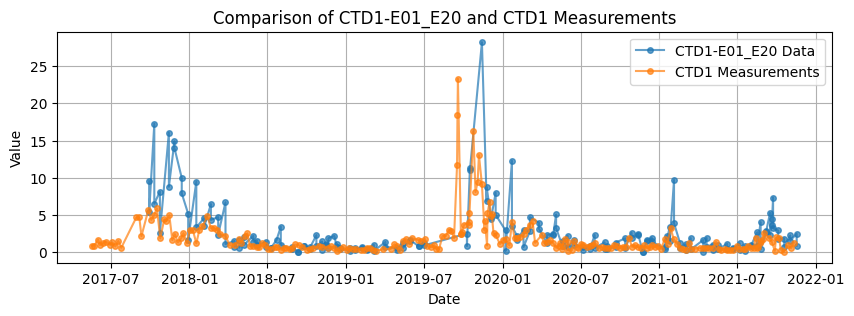

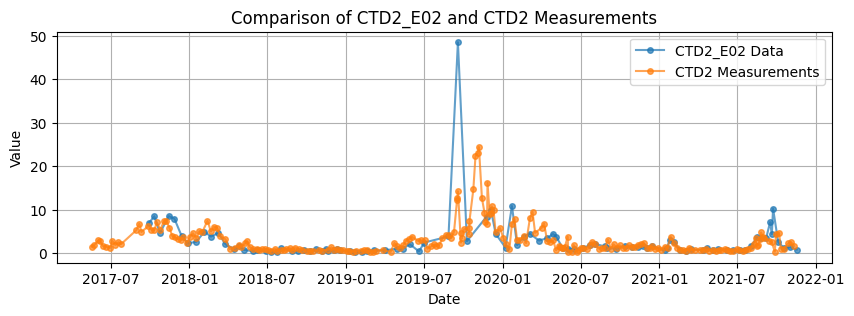

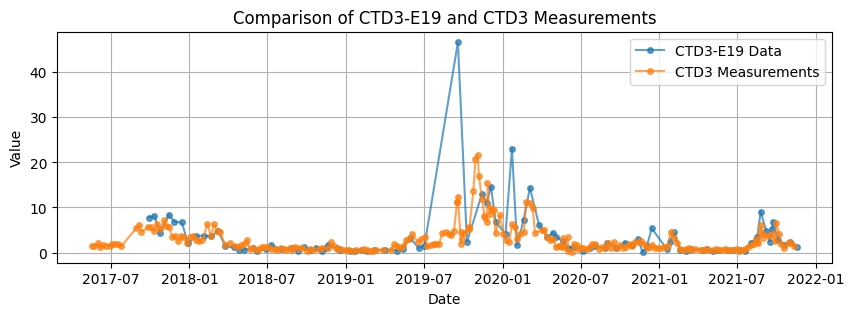

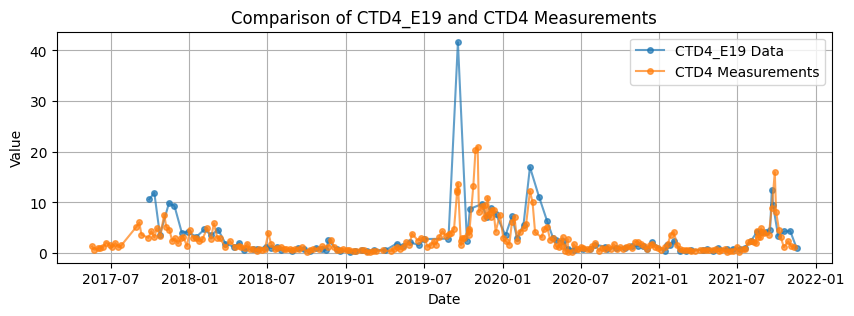

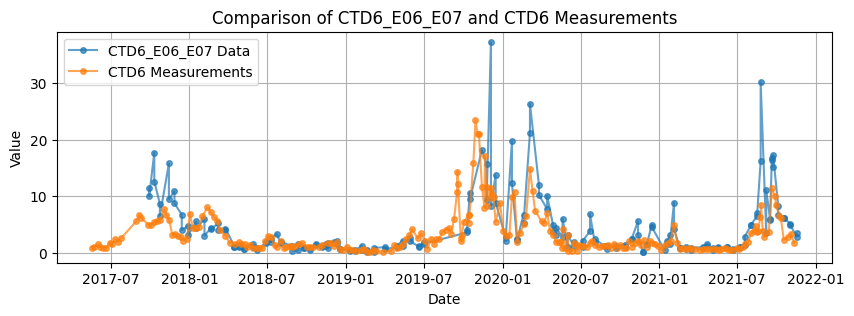

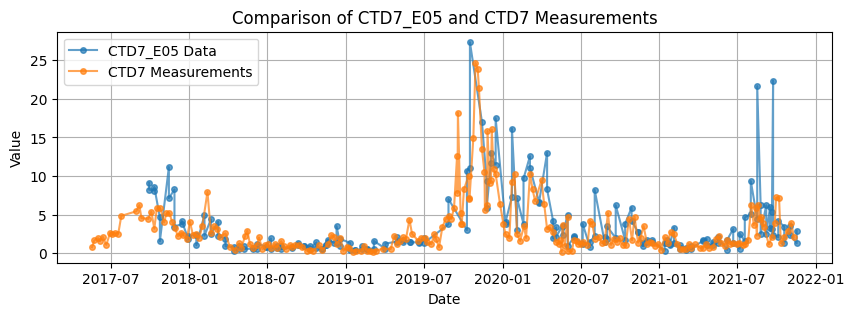

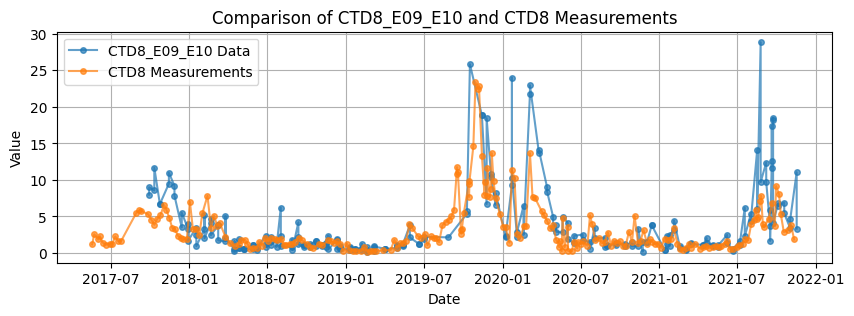

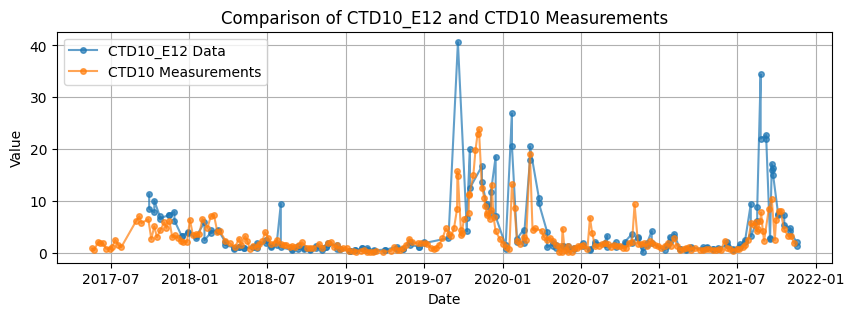

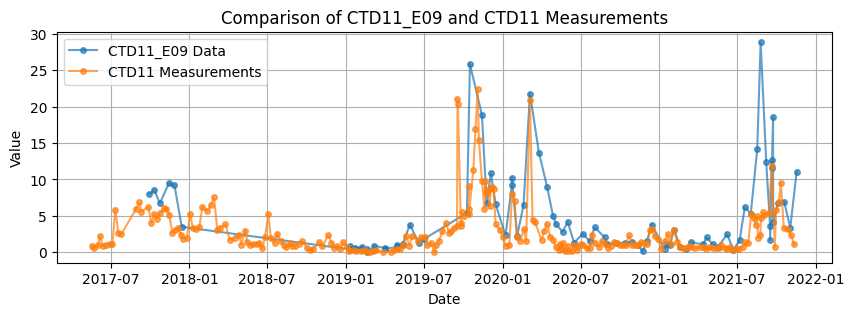

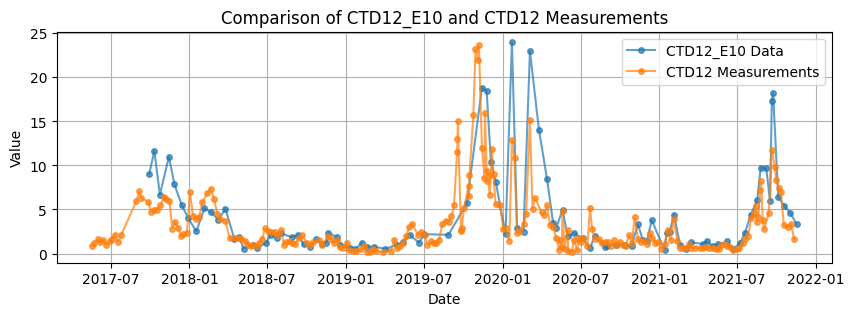

In [62]:
def extract_location(sheet_name):
    return sheet_name.split('-')[0].split('_')[0]

# Iterate over dictionary of DataFrames
for sheet_name, df in dfs.items():
    location = extract_location(sheet_name)  # Extract location identifier
    
    # Check if the location exists in df_other
    if location in df_boyas['Buoy'].unique():

        #df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%y", errors="coerce")
        df_boyas_filtered = df_boyas[df_boyas["Buoy"] == location]

        plt.figure(figsize=(10, 3))
        plt.plot(df["Date"], df["Chl-a"], label=f"{sheet_name} Data", marker="o", markersize=4, alpha=0.7)
        #plt.scatter(df_boyas_filtered["Date"], df_boyas_filtered["Chl"], label=f"{location} Measurements", color='red', alpha=0.6, s=15)
        plt.plot(df_boyas_filtered["Date"], df_boyas_filtered["Chl"], label=f"{location} Measurements", marker="o", markersize=4, alpha=0.7)
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.title(f"Comparison of {sheet_name} and {location} Measurements")
        plt.legend()
        plt.grid(True)
        plt.show()